# Campus Recruitment Prediction

## 1. Data Preprocessing and Exploratory Data Analysis (EDA)

In [17]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df=pd.read_csv("/content/drive/MyDrive/Placement_Data_Full_Class.csv")
df.shape
df


,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,214,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    object 
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    object 
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    object 
 6   hsc_s           215 non-null    object 
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    object 
 9   workex          215 non-null    object 
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    object 
 12  mba_p           215 non-null    float64
 13  status          215 non-null    object 
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 25.3+ KB


In [21]:
df.describe()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,148.000000
mean,108.000000,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
std,62.209324,10.827205,10.897509,7.358743,13.275956,5.833385,93457.452420
min,1.000000,40.890000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,54.500000,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000
50%,108.000000,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
75%,161.500000,75.700000,73.000000,72.000000,83.500000,66.255000,300000.000000
max,215.000000,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


In [22]:
#missing vals
print(df.isnull().sum())

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64


In [23]:
#handling with mean of salary
df['salary'] = df['salary'].fillna(df['salary'].mean())
"""df.dropna(inplace=True)"""
print(df.isnull().sum())

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64


In [24]:
df.shape

(215, 15)

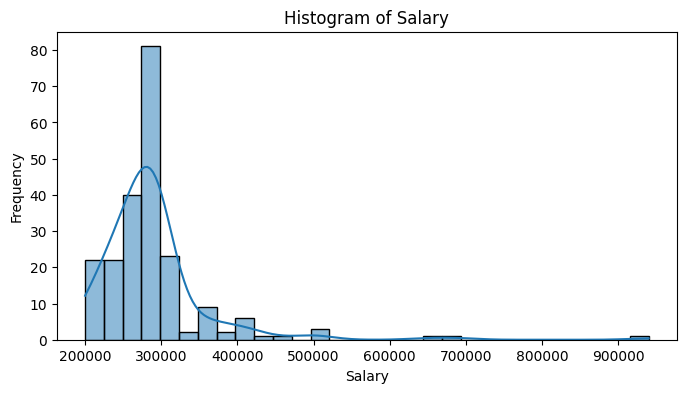

In [26]:
# distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['salary'], bins=30, kde=True)
plt.title('Histogram of Salary')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()


In [28]:
# outliers

Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[df['salary'] > upper_bound]
print("Detected Outliers:")
print(outliers[['sl_no', 'salary']])
print("Number of Outliers:", outliers.shape[0])

# remove
df_no_outliers = df[df['salary'] <= upper_bound]
print(" dataset shape after removing outliers:", df_no_outliers.shape)



Detected Outliers:
     sl_no    salary
4        5  425000.0
21      22  393000.0
22      23  360000.0
24      25  360000.0
28      29  350000.0
39      40  411000.0
53      54  450000.0
57      58  360000.0
70      71  360000.0
77      78  500000.0
85      86  400000.0
95      96  420000.0
101    102  380000.0
104    105  360000.0
119    120  940000.0
125    126  350000.0
128    129  400000.0
131    132  360000.0
145    146  400000.0
150    151  690000.0
163    164  500000.0
174    175  500000.0
177    178  650000.0
178    179  350000.0
210    211  400000.0
Number of Outliers: 25
 dataset shape after removing outliers: (190, 15)


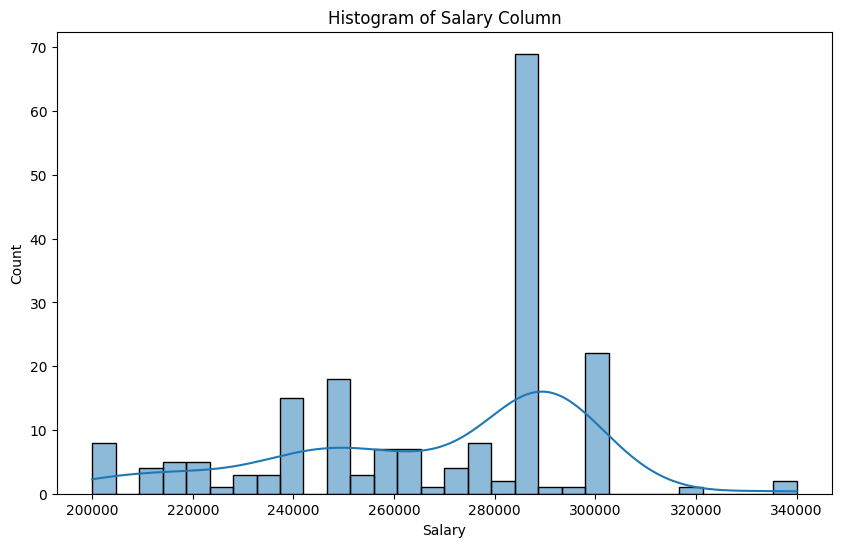

In [29]:
# distribution after remove

plt.figure(figsize=(10, 6))

sns.histplot(df_no_outliers['salary'], bins=30, kde=True)

plt.title('Histogram of Salary Column')
plt.xlabel('Salary')

plt.show()



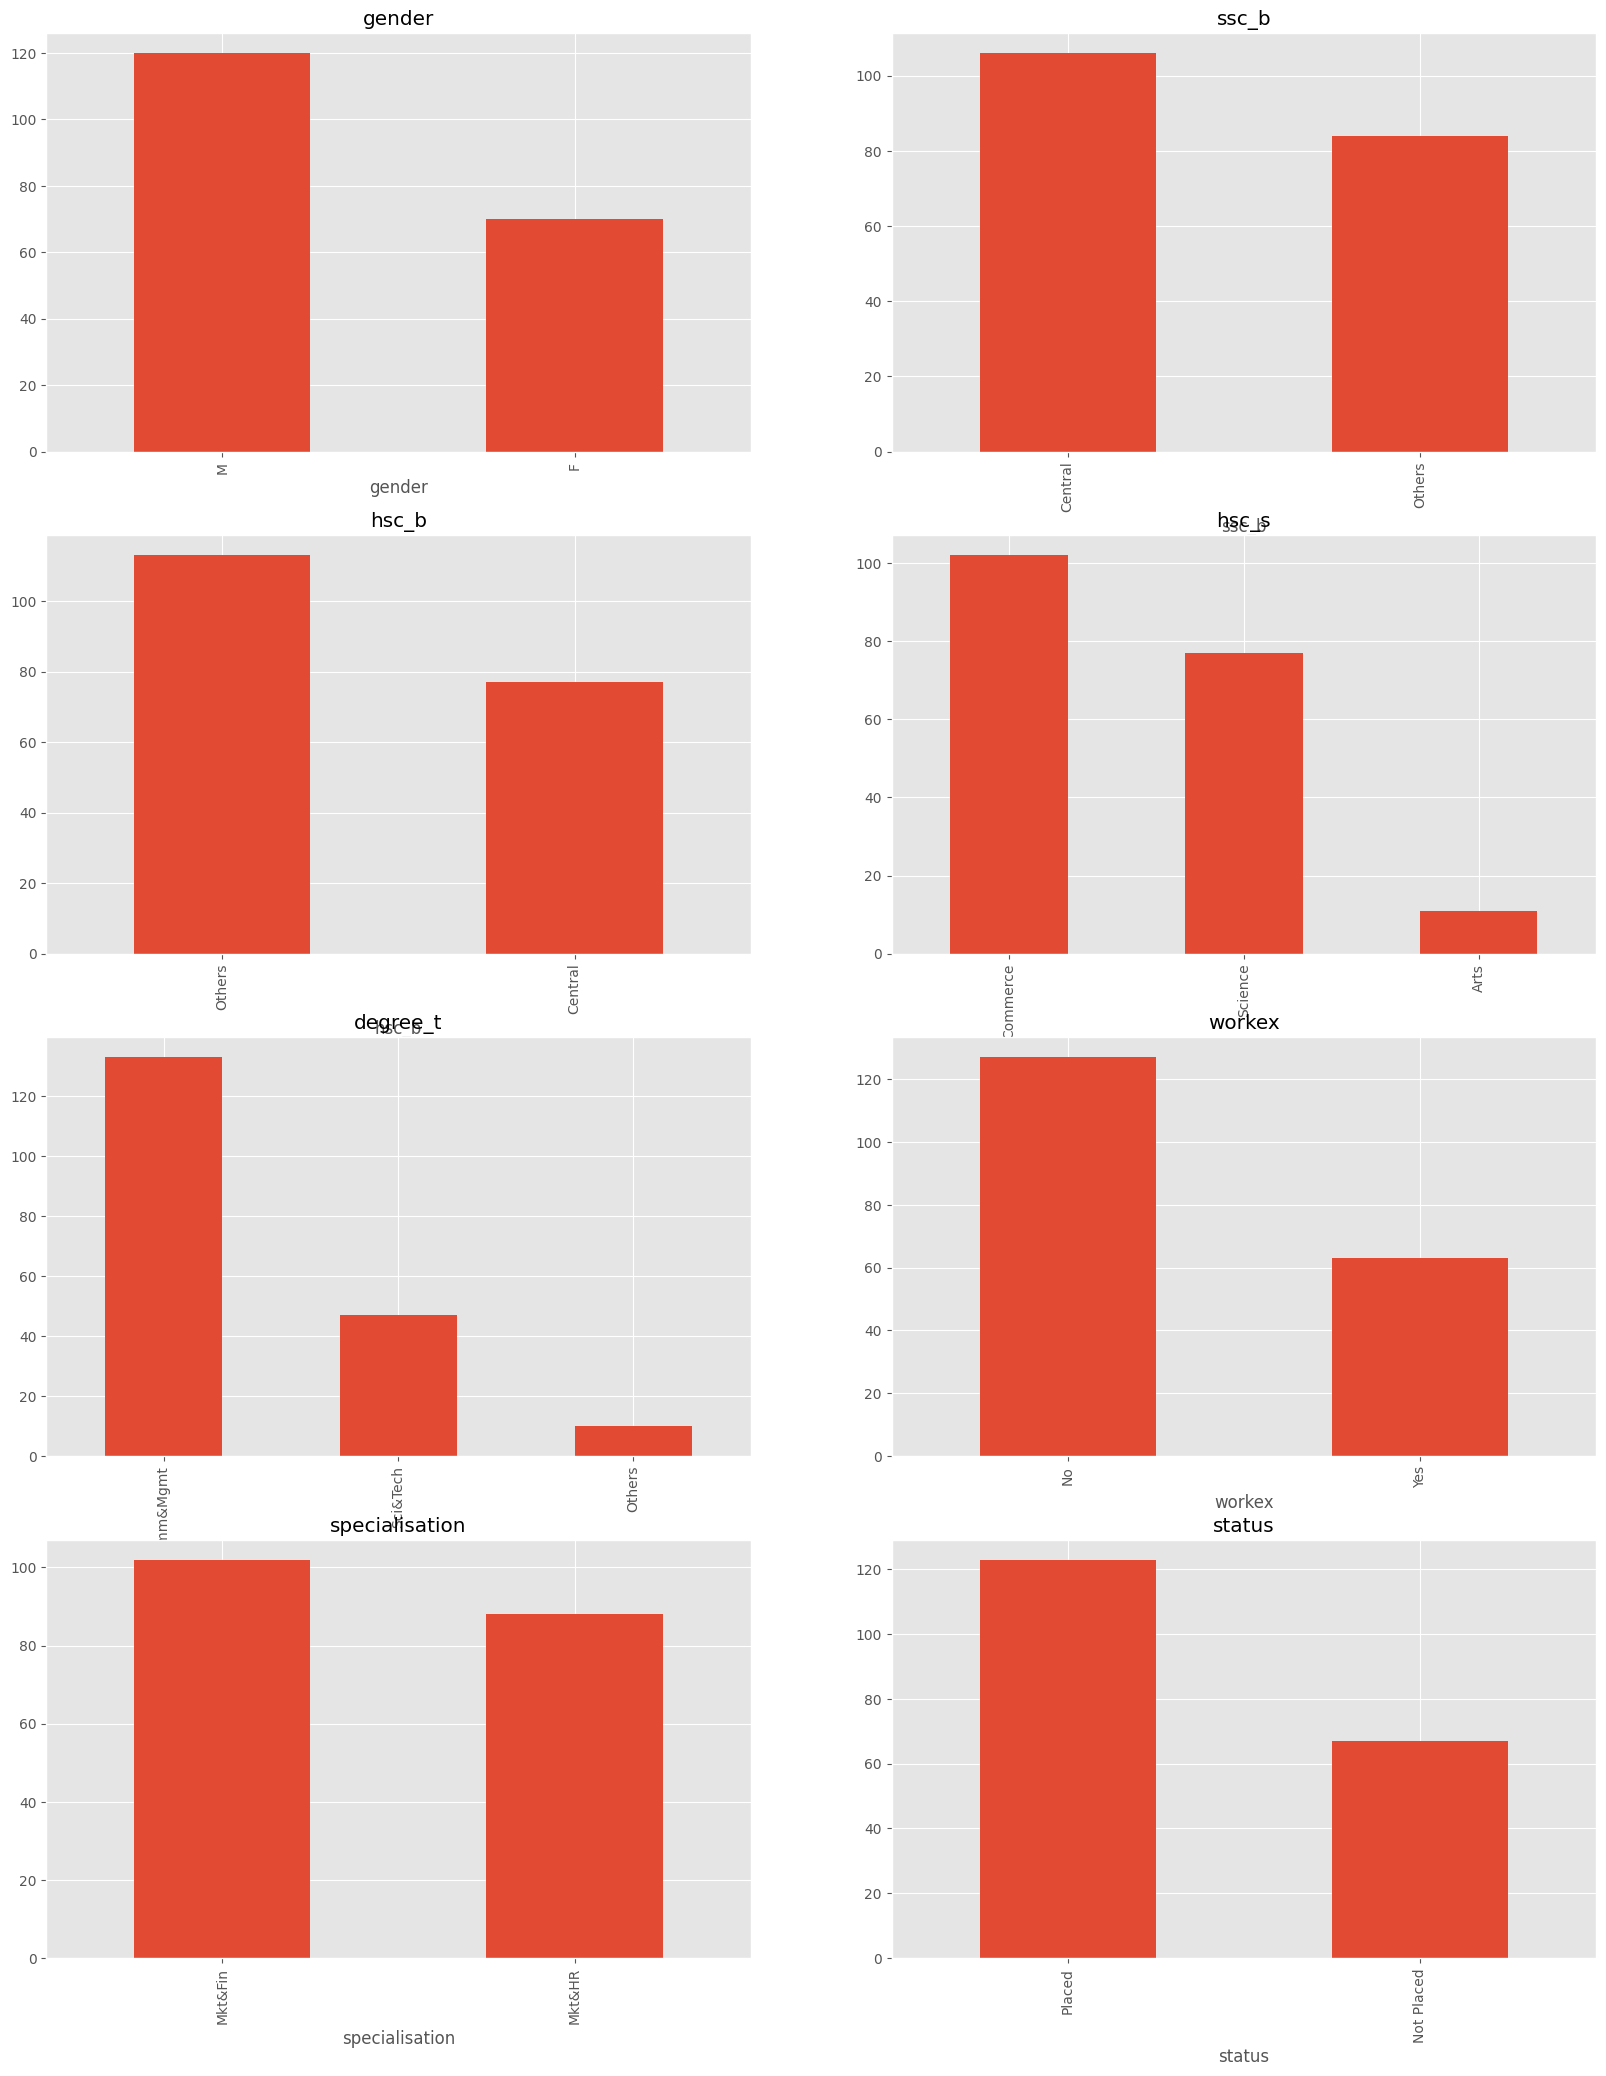

In [30]:
plt.style.use('ggplot')
plt.figure(figsize=(20,25))
plt.subplot(4,2,1)
df_no_outliers['gender'].value_counts().plot(kind='bar',title='gender')
plt.subplot(4,2,2)
df_no_outliers['ssc_b'].value_counts().plot(kind='bar',title='ssc_b')
plt.subplot(4,2,3)
df_no_outliers['hsc_b'].value_counts().plot(kind='bar',title='hsc_b')
plt.subplot(4,2,4)
df_no_outliers['hsc_s'].value_counts().plot(kind='bar',title='hsc_s')
plt.subplot(4,2,5)
df_no_outliers['degree_t'].value_counts().plot(kind='bar',title='degree_t')
plt.subplot(4,2,6)
df_no_outliers['workex'].value_counts().plot(kind='bar',title='workex')
plt.subplot(4,2,7)
df_no_outliers['specialisation'].value_counts().plot(kind='bar',title='specialisation')
plt.subplot(4,2,8)
df_no_outliers['status'].value_counts().plot(kind='bar',title='status')
plt.show()

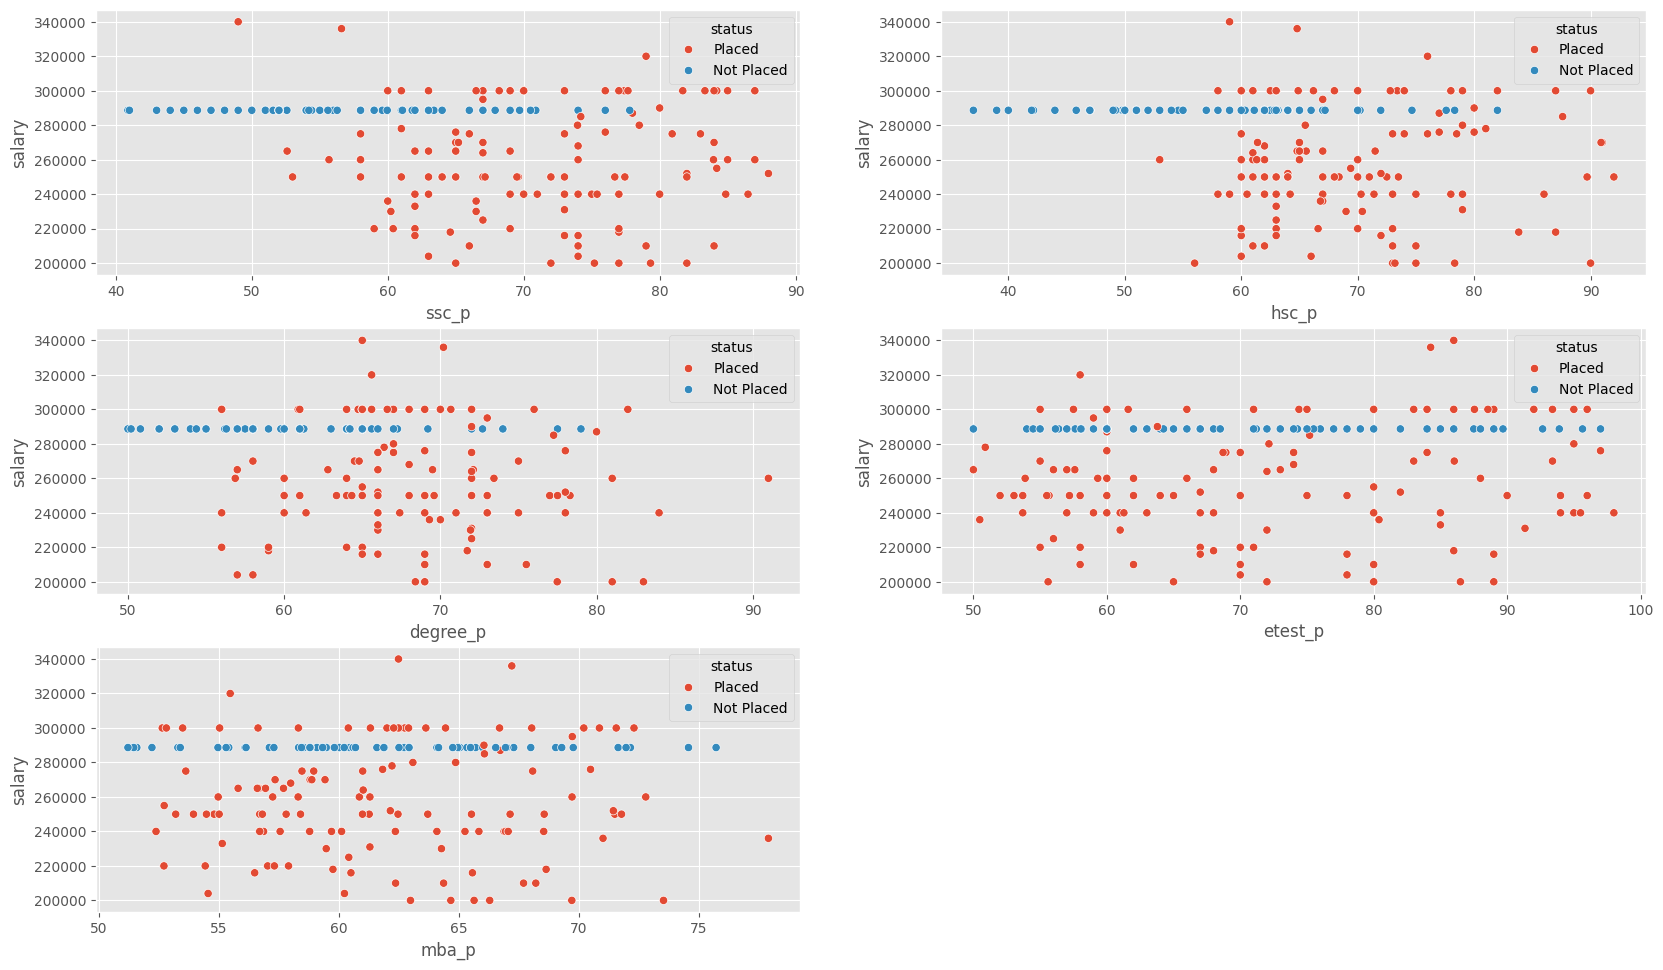

In [ ]:
plt.figure(figsize=(20,20))
plt.subplot(5,2,1)
sns.scatterplot(data=df_no_outliers, x="ssc_p", y="salary", hue="status")
plt.subplot(5,2,2)
sns.scatterplot(data=df_no_outliers, x="hsc_p", y="salary", hue="status")
plt.subplot(5,2,3)
sns.scatterplot(data=df_no_outliers, x="degree_p", y="salary", hue="status")
plt.subplot(5,2,4)
sns.scatterplot(data=df_no_outliers, x="etest_p", y="salary", hue="status")
plt.subplot(5,2,5)
sns.scatterplot(data=df_no_outliers, x="mba_p", y="salary", hue="status")
plt.show()

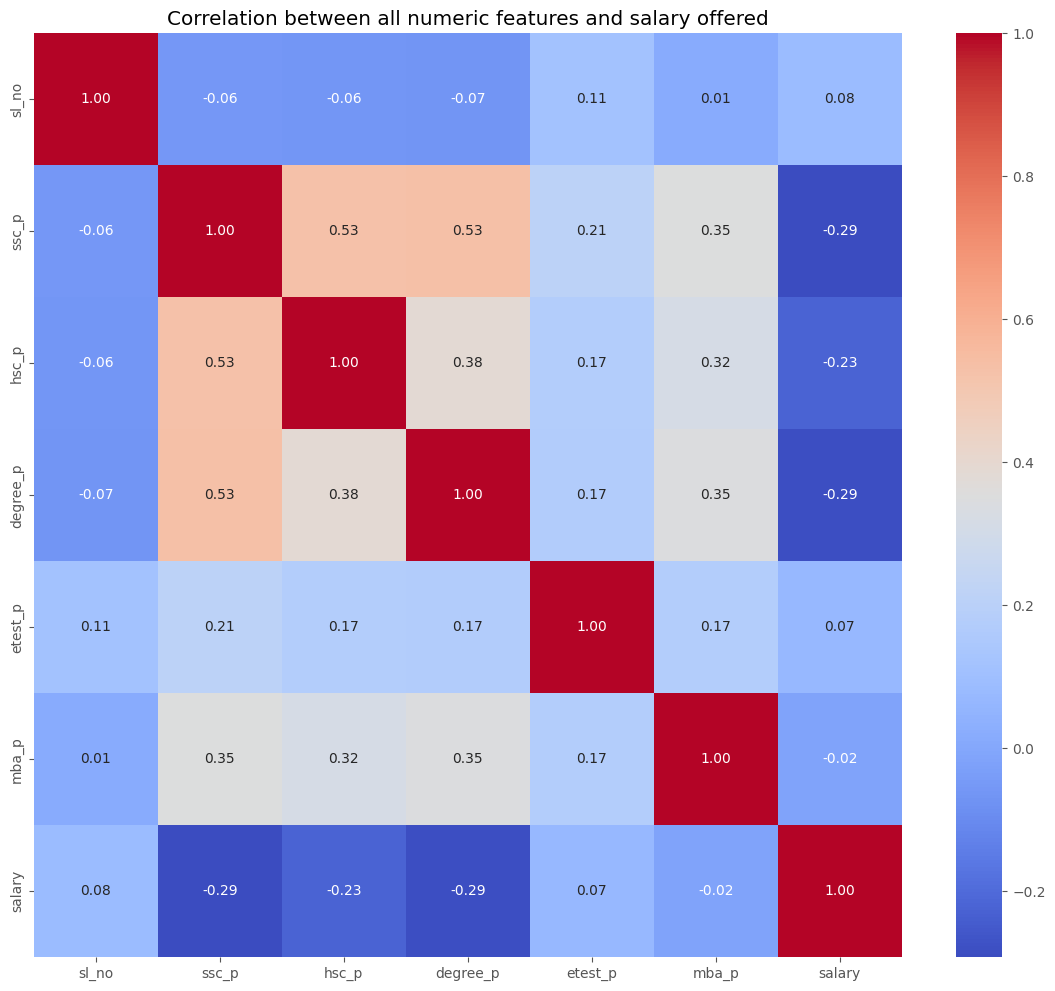

In [ ]:
# Select only numeric columns for correlation
df_corr = df_no_outliers.select_dtypes(include=['number'])

# Plot correlation heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation between all numeric features and salary offered')
plt.show()

## 2. Model Development and Evaluation

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd


df_class = df_no_outliers.copy()

# Drop irrelevant or leakage-causing columns
df_class = df_class.drop(columns=['sl_no', 'salary'])
df_class.dropna(inplace=True)

# Encode target variable
df_class['status'] = LabelEncoder().fit_transform(df_class['status'])  # 1 = Placed, 0 = Not Placed


binary_cols = ['gender', 'ssc_b', 'hsc_b', 'workex', 'specialisation']
multi_class_cols = ['hsc_s', 'degree_t']

# Apply Label Encoding to binary categorical columns
label_encoders = {}
for col in binary_cols:
    le = LabelEncoder()
    df_class[col] = le.fit_transform(df_class[col])
    label_encoders[col] = le

# Apply One-Hot Encoding to multi-class categorical columns
df_class = pd.get_dummies(df_class, columns=multi_class_cols, drop_first=True)


X = df_class.drop('status', axis=1)
y = df_class['status']

# Split into training and testing sets FIRST before normalization
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalize numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve


In [33]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    print(name)
    model.fit(X_train, y_train)

    for X, y, label in [(X_train, y_train, "Train"), (X_test, y_test, "Test")]:
        y_pred = model.predict(X)
        y_proba = model.predict_proba(X)[:, 1]

        acc = accuracy_score(y, y_pred)
        prec = precision_score(y, y_pred)
        rec = recall_score(y, y_pred)
        f1 = f1_score(y, y_pred)
        roc = roc_auc_score(y, y_proba)

        print(f"\n {label} Metrics:")
        print(f"Accuracy:  {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall:    {rec:.4f}")
        print(f"F1-Score:  {f1:.4f}")
        print(f"ROC-AUC:   {roc:.4f}")
        print("-------------------------------------------------------")

        # confusion matrix
        cm = confusion_matrix(y, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f"{name} - Confusion Matrix ({label})")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()
        print("-------------------------------------------------------")
        # ROC curve
        fpr, tpr, _ = roc_curve(y, y_proba)
        plt.plot(fpr, tpr, label=f"{label} (AUC = {roc:.2f})")
        print("-------------------------------------------------------")

    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f"{name} - ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()
    print("-------------------------------------------------------")

    # precision recall curve
    precision, recall, _ = precision_recall_curve(y_test, model.predict_proba(X_test)[:, 1])
    plt.plot(recall, precision, label=name)
    plt.title(f"{name} - Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.show()
    print("-------------------------------------------------------")

Logistic Regression

 Train Metrics:
Accuracy:  0.8882
Precision: 0.9010
Recall:    0.9286
F1-Score:  0.9146
ROC-AUC:   0.9571
-------------------------------------------------------


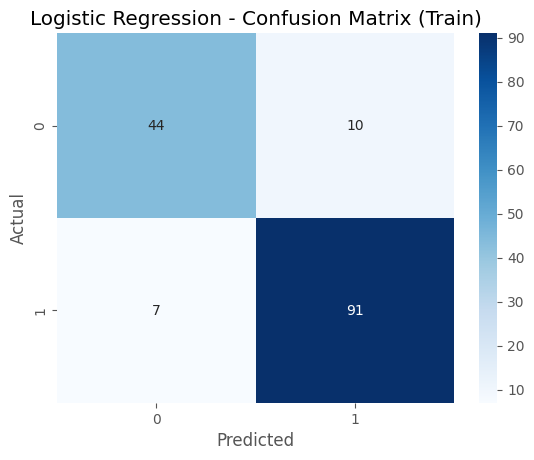

-------------------------------------------------------
-------------------------------------------------------

 Test Metrics:
Accuracy:  0.9474
Precision: 0.9259
Recall:    1.0000
F1-Score:  0.9615
ROC-AUC:   0.9846
-------------------------------------------------------


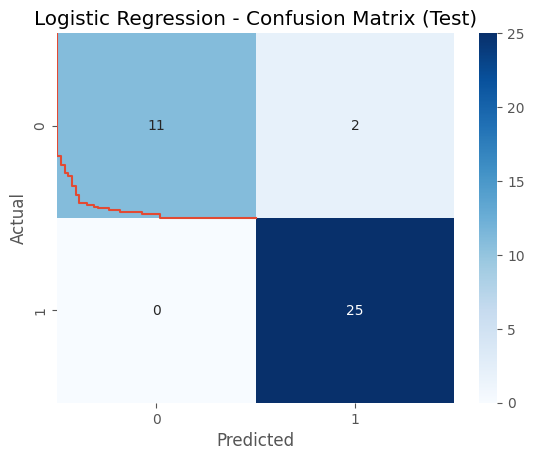

-------------------------------------------------------
-------------------------------------------------------


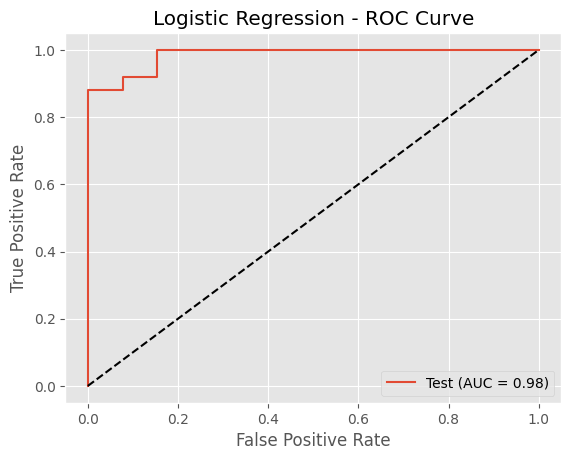

-------------------------------------------------------


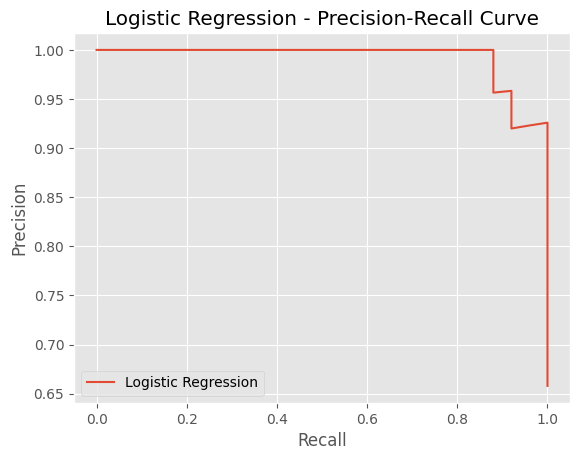

-------------------------------------------------------


In [36]:
evaluate_model('Logistic Regression', LogisticRegression(), X_train, X_test, y_train, y_test)

NB

 Train Metrics:
Accuracy:  0.8224
Precision: 0.8257
Recall:    0.9184
F1-Score:  0.8696
ROC-AUC:   0.8923
-------------------------------------------------------


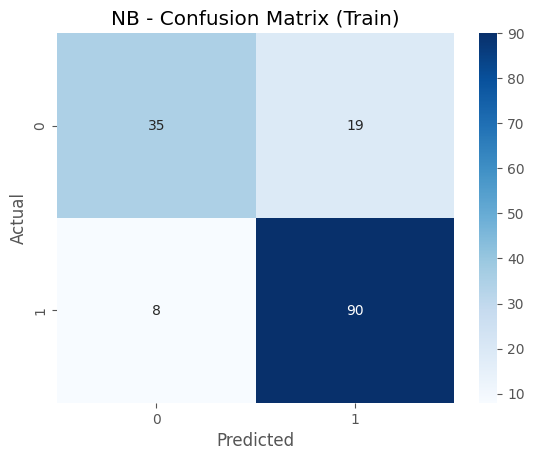

-------------------------------------------------------
-------------------------------------------------------

 Test Metrics:
Accuracy:  0.8158
Precision: 0.8214
Recall:    0.9200
F1-Score:  0.8679
ROC-AUC:   0.9138
-------------------------------------------------------


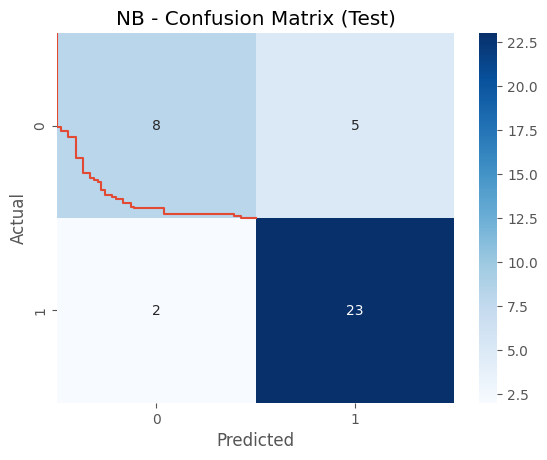

-------------------------------------------------------
-------------------------------------------------------


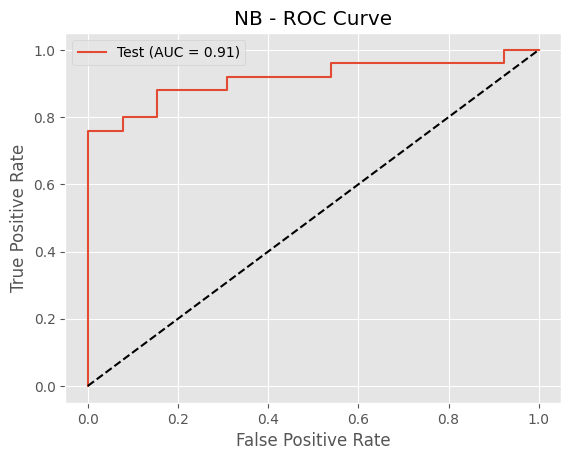

-------------------------------------------------------


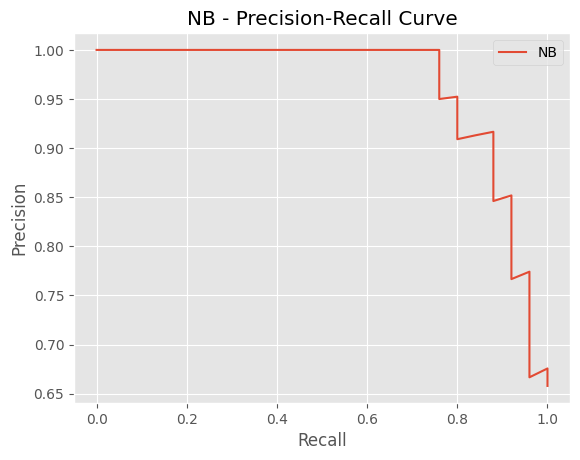

-------------------------------------------------------


In [37]:
evaluate_model('NB', GaussianNB(), X_train, X_test, y_train, y_test)

LDA

 Train Metrics:
Accuracy:  0.8947
Precision: 0.9100
Recall:    0.9286
F1-Score:  0.9192
ROC-AUC:   0.9548
-------------------------------------------------------


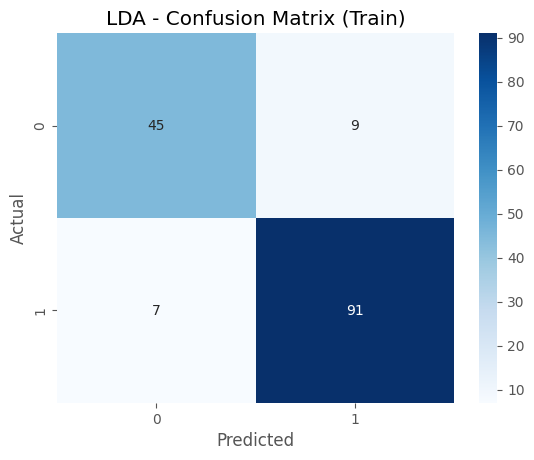

-------------------------------------------------------
-------------------------------------------------------

 Test Metrics:
Accuracy:  0.9474
Precision: 0.9259
Recall:    1.0000
F1-Score:  0.9615
ROC-AUC:   0.9723
-------------------------------------------------------


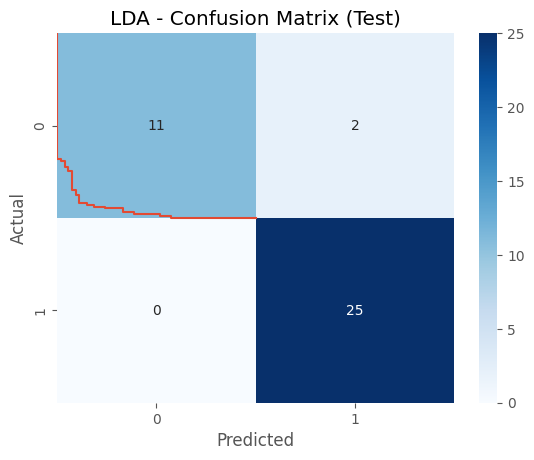

-------------------------------------------------------
-------------------------------------------------------


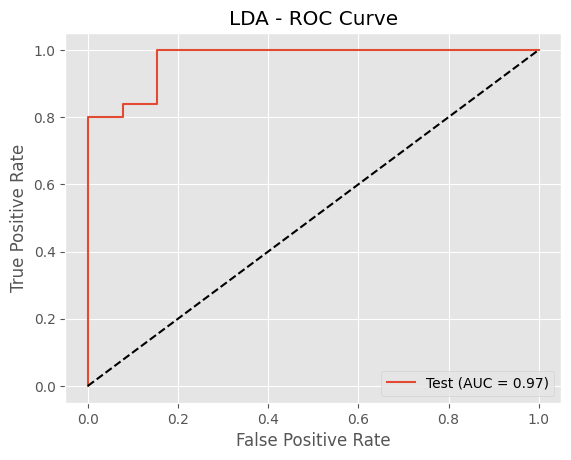

-------------------------------------------------------


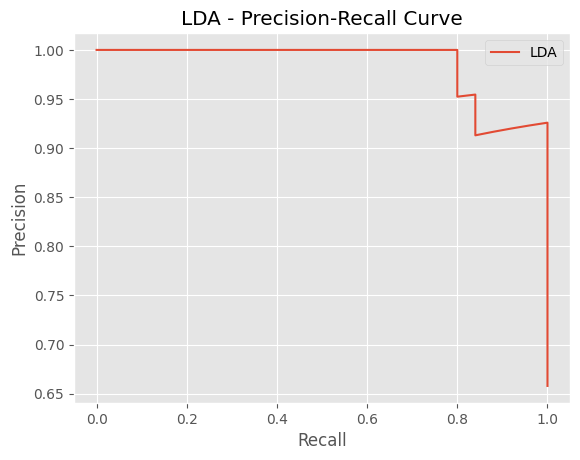

-------------------------------------------------------


In [38]:
evaluate_model('LDA', LinearDiscriminantAnalysis(), X_train, X_test, y_train, y_test)

Best Performing Model:
Linear Regression and LDA both have the same accuracy, precision, recall, and F1-score on the test set, with Linear Regression achieving a slightly higher ROC-AUC (98.46% vs. 97.23% for LDA). While Linear Regression performs slightly better, LDA is often preferred over Linear Regression for classification tasks because it works better with categorical labels and is more robust in many cases, especially when the assumptions of the model hold

the problem here is that in Log Reg and LDA for test the Recall is 1. A recall of 1 means that the model correctly identified all actual positive cases—in this context, it predicted every student who was truly "Placed" as "Placed." While this sounds ideal, it's often a red flag because it can indicate that the model is overpredicting the positive class, possibly labeling nearly all cases as "Placed" just to avoid missing any, which leads to many false positives and low precision. This behavior suggests the model is not truly learning meaningful patterns, especially in imbalanced datasets, and may not generalize well to unseen data.

In [40]:
y.value_counts(normalize=True)


,proportion
status,
1,0.647368
0,0.352632


In [41]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
print(classification_report(y_test, dummy.predict(X_test)))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.66      1.00      0.79        25

    accuracy                           0.66        38
   macro avg       0.33      0.50      0.40        38
weighted avg       0.43      0.66      0.52        38



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [42]:

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))


status
1    0.644737
0    0.355263
Name: proportion, dtype: float64
status
1    0.657895
0    0.342105
Name: proportion, dtype: float64


## 3. Performance Enhancement

Logistic Regression (Ridge/L2)

Train Metrics:
Accuracy:  0.9013
Precision: 0.9368
Recall:    0.9082
F1-Score:  0.9223
ROC-AUC:   0.9558
-------------------------------------------------------


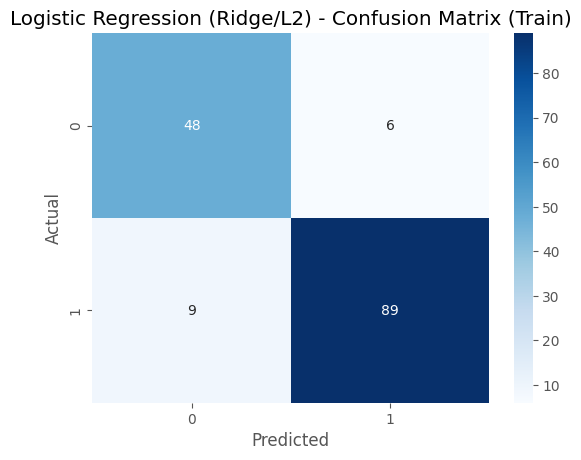

-------------------------------------------------------
-------------------------------------------------------

Test Metrics:
Accuracy:  0.8947
Precision: 0.9200
Recall:    0.9200
F1-Score:  0.9200
ROC-AUC:   0.9846
-------------------------------------------------------


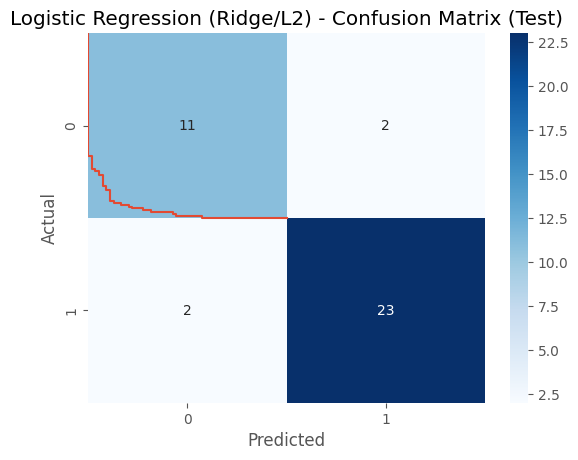

-------------------------------------------------------
-------------------------------------------------------


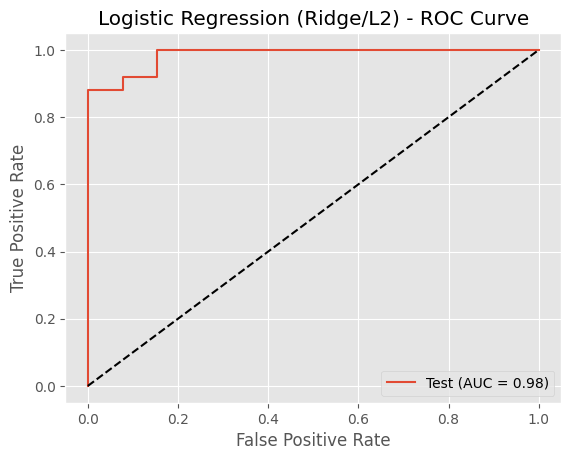

-------------------------------------------------------


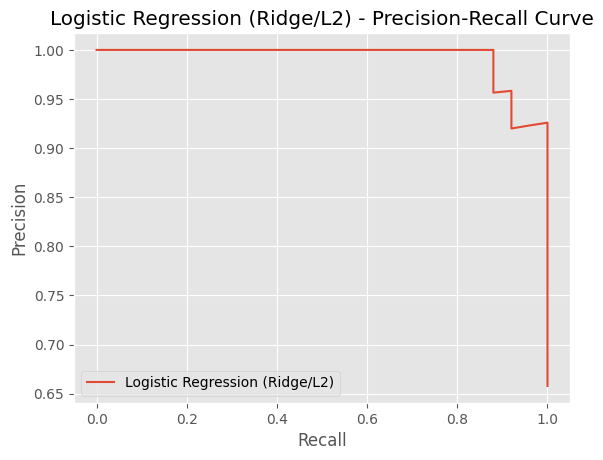

-------------------------------------------------------
Logistic Regression (Lasso/L1)

Train Metrics:
Accuracy:  0.8882
Precision: 0.9355
Recall:    0.8878
F1-Score:  0.9110
ROC-AUC:   0.9562
-------------------------------------------------------


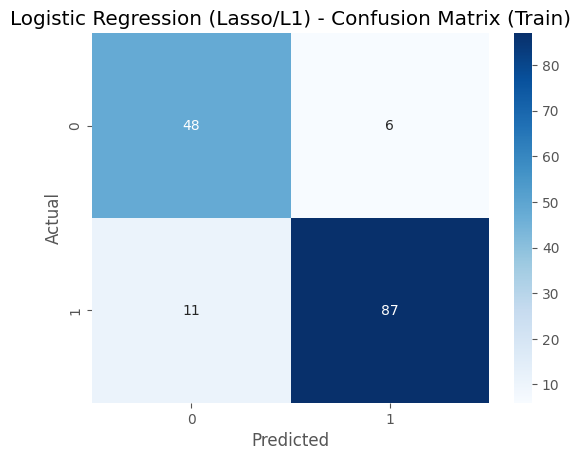

-------------------------------------------------------
-------------------------------------------------------

Test Metrics:
Accuracy:  0.9474
Precision: 0.9600
Recall:    0.9600
F1-Score:  0.9600
ROC-AUC:   0.9908
-------------------------------------------------------


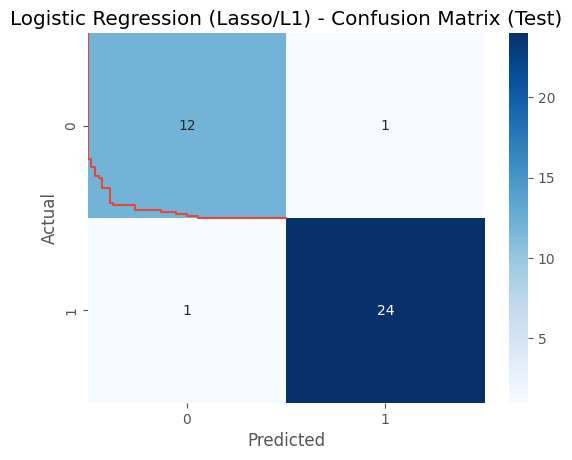

-------------------------------------------------------
-------------------------------------------------------


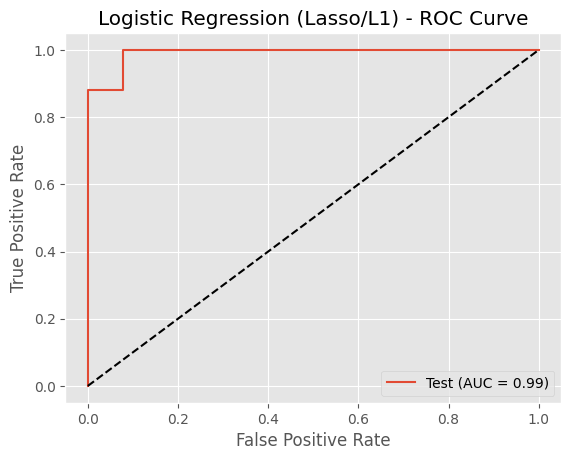

-------------------------------------------------------


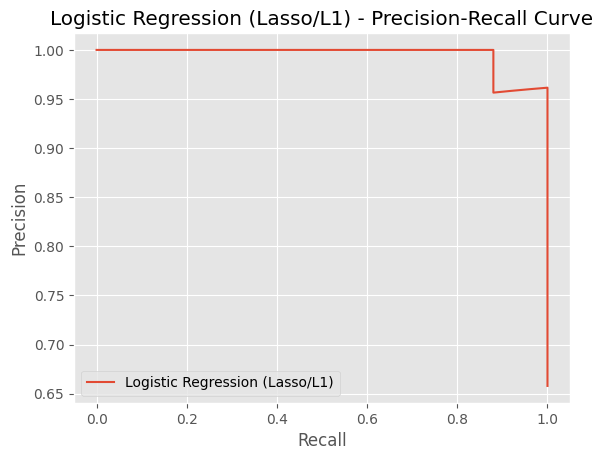

-------------------------------------------------------


In [43]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve


def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    print(name)
    model.fit(X_train, y_train)

    for X, y, label in [(X_train, y_train, "Train"), (X_test, y_test, "Test")]:
        y_pred = model.predict(X)
        y_proba = model.predict_proba(X)[:, 1]

        acc = accuracy_score(y, y_pred)
        prec = precision_score(y, y_pred)
        rec = recall_score(y, y_pred)
        f1 = f1_score(y, y_pred)
        roc = roc_auc_score(y, y_proba)

        print(f"\n{label} Metrics:")
        print(f"Accuracy:  {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall:    {rec:.4f}")
        print(f"F1-Score:  {f1:.4f}")
        print(f"ROC-AUC:   {roc:.4f}")
        print("-------------------------------------------------------")
        # Confusion matrix
        cm = confusion_matrix(y, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f"{name} - Confusion Matrix ({label})")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()
        print("-------------------------------------------------------")
        # ROC Curve
        fpr, tpr, _ = roc_curve(y, y_proba)
        plt.plot(fpr, tpr, label=f"{label} (AUC = {roc:.2f})")
        print("-------------------------------------------------------")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f"{name} - ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()
    print("-------------------------------------------------------")
    # Precision-Recall Curve (only once for test set)
    precision, recall, _ = precision_recall_curve(y_test, model.predict_proba(X_test)[:, 1])
    plt.plot(recall, precision, label=name)
    plt.title(f"{name} - Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.show()
    print("-------------------------------------------------------")
# Logistic Regression with L2 (Ridge)
logreg_l2 = LogisticRegressionCV(
    Cs=10,
    cv=5,
    penalty='l2',
    scoring='roc_auc',
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
evaluate_model("Logistic Regression (Ridge/L2)", logreg_l2, X_train, X_test, y_train, y_test)

# Logistic Regression with L1 (Lasso)
logreg_l1 = LogisticRegressionCV(
    Cs=10,
    cv=5,
    penalty='l1',
    scoring='roc_auc',
    solver='liblinear',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
evaluate_model("Logistic Regression (Lasso/L1)", logreg_l1, X_train, X_test, y_train, y_test)


This code applies logistic regression with L1 (Lasso) and L2 (Ridge) regularization using cross-validation to automatically select the best regularization strength (`C`) and includes `class_weight='balanced'` to correct for class imbalance, which is often the cause of unrealistically high recall (like 1.0). The `class_weight='balanced'` parameter tells the model to penalize misclassification of minority and majority classes proportionally to their frequency, helping it avoid simply predicting the dominant class (e.g., always "Placed"). By doing so, the model becomes more sensitive to both classes, leading to more realistic recall and precision values, and better generalization. The evaluation function reports key metrics (accuracy, precision, recall, F1, ROC-AUC) for both training and testing sets and visualizes confusion matrices and performance curves to assess model behavior more clearly.


In this comparison of classification models Logistic Regression with Lasso (L1 regularization) emerges as the best performer achieving high metrics across the board with an accuracy of 94.74% precision and recall both at 96% and a perfect F1-score of 0.96. This model also boasts the highest ROC-AUC score of 0.9908 indicating strong overall performance. Logistic Regression without regularization follows closely with similar results also showing excellent precision and recall. LDA also performs very well mirroring Logistic Regression's performance but with a slightly lower ROC-AUC. Naive Bayes while still useful lags behind with lower accuracy (81.58%) and F1-score (0.86) highlighting its weaker performance likely due to its assumption of feature independence. Logistic Regression with Ridge (L2 regularization) performs similarly to the standard logistic model but with a slight drop in accuracy and F1-score suggesting that L2 regularization may be too aggressive for this dataset. Therefore Logistic Regression with Lasso (L1) stands out as the top-performing model offering a balanced and reliable solution.

| Model               | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
| ------------------- | -------- | --------- | ------ | -------- | ------- |
| Logistic Regression | 0.9474   | 0.9259    | 1.000  | 0.9615   | 0.9846  |
| Naive Bayes         | 0.8158   | 0.8214    | 0.920  | 0.8679   | 0.9138  |
| LDA                 | 0.9474   | 0.9259    | 1.000  | 0.9615   | 0.9723  |
| Logistic (Lasso/L1) | 0.9474   | 0.9600    | 0.960  | 0.9600   | 0.9908  |
| Logistic (Ridge/L2) | 0.8947   | 0.9200    | 0.920  | 0.9200   | 0.9846  |
